# MONZA × jpt — Análise gráfica dos resultados

Pipeline FL real (PFLlibMonza, FedAvgCNN/MNIST, 100 clientes, 30 maliciosos, 50 rounds) com 4 defesas comparadas:

- **cc=2** — Cluster cosseno (PFLlib baseline)
- **cc=3** — Cosseno + score (PFLlib baseline)
- **cc=6** — NLP DistilBERT+LoRA (este trabalho)
- **cc=7** — MLP+features (este trabalho)

Detalhes em `MONZA_RESULTS.md`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

JPT = Path('/home/wallace/Projetcs/Rafael/jpt')
MONZA = Path('/home/wallace/Projetcs/Rafael/PFLlibMonza/system')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

## 1. Carregar CSVs (FPR/FRR por round)

`cc=2` e `cc=3` foram rodadas duas vezes (acumulam linhas). Filtro tolerante: remove headers duplicados, detecta inicio do último run pelo Round voltando a 0.

In [2]:
def load_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Linhas com 'Round' como string sao headers duplicados
    df = df[df['Round'] != 'Round'].reset_index(drop=True)
    df = df.astype({'Round': int, 'FPR': float, 'FRR': float})

    # Detectar inicio do ultimo run: Round volta pra um valor menor.
    last_start = 0
    prev = -1
    for i, r in enumerate(df['Round'].values):
        if r < prev:
            last_start = i
        prev = r
    return df.iloc[last_start:].reset_index(drop=True)


DEFENSES = {
    'cc=2 (cluster cosseno)': MONZA / 'fpr_frr_results_2.csv',
    'cc=3 (cosseno+score)': MONZA / 'fpr_frr_results_3.csv',
    'cc=6 (NLP DistilBERT)': MONZA / 'fpr_frr_results_6.csv',
    'cc=7 (MLP+features)': MONZA / 'fpr_frr_results_7.csv',
}

dfs = {name: load_csv(path) for name, path in DEFENSES.items()}
for name, df in dfs.items():
    print(f'{name:32s} | {len(df)} rounds | FPR last: {df.FPR.iloc[-1]:.4f} | FRR last: {df.FRR.iloc[-1]:.4f}')

cc=2 (cluster cosseno)           | 51 rounds | FPR last: 0.0000 | FRR last: 0.2000
cc=3 (cosseno+score)             | 51 rounds | FPR last: 0.0000 | FRR last: 0.4333
cc=6 (NLP DistilBERT)            | 51 rounds | FPR last: 0.0000 | FRR last: 0.1667
cc=7 (MLP+features)              | 51 rounds | FPR last: 0.0000 | FRR last: 0.2333


## 2. Tabela de médias dos últimos 30 rounds

In [3]:
rows = []
for name, df in dfs.items():
    last30 = df.tail(30)
    rows.append({
        'Defesa': name,
        'FPR_mean': last30['FPR'].mean(),
        'FPR_std': last30['FPR'].std(),
        'FRR_mean': last30['FRR'].mean(),
        'FRR_std': last30['FRR'].std(),
        'Score (FPR+FRR)': last30['FPR'].mean() + last30['FRR'].mean(),
    })
summary = pd.DataFrame(rows).sort_values('Score (FPR+FRR)').reset_index(drop=True)
summary

,Defesa,FPR_mean,FPR_std,FRR_mean,FRR_std,Score (FPR+FRR)
0,cc=7 (MLP+features),0.000000,0.000000,0.155556,0.094010,0.155556
1,cc=3 (cosseno+score),0.053333,0.111791,0.114444,0.153049,0.167778
2,cc=6 (NLP DistilBERT),0.112381,0.167892,0.114444,0.130041,0.226825
3,cc=2 (cluster cosseno),0.000000,0.000000,0.262222,0.076681,0.262222


## 3. Curvas FPR e FRR por round

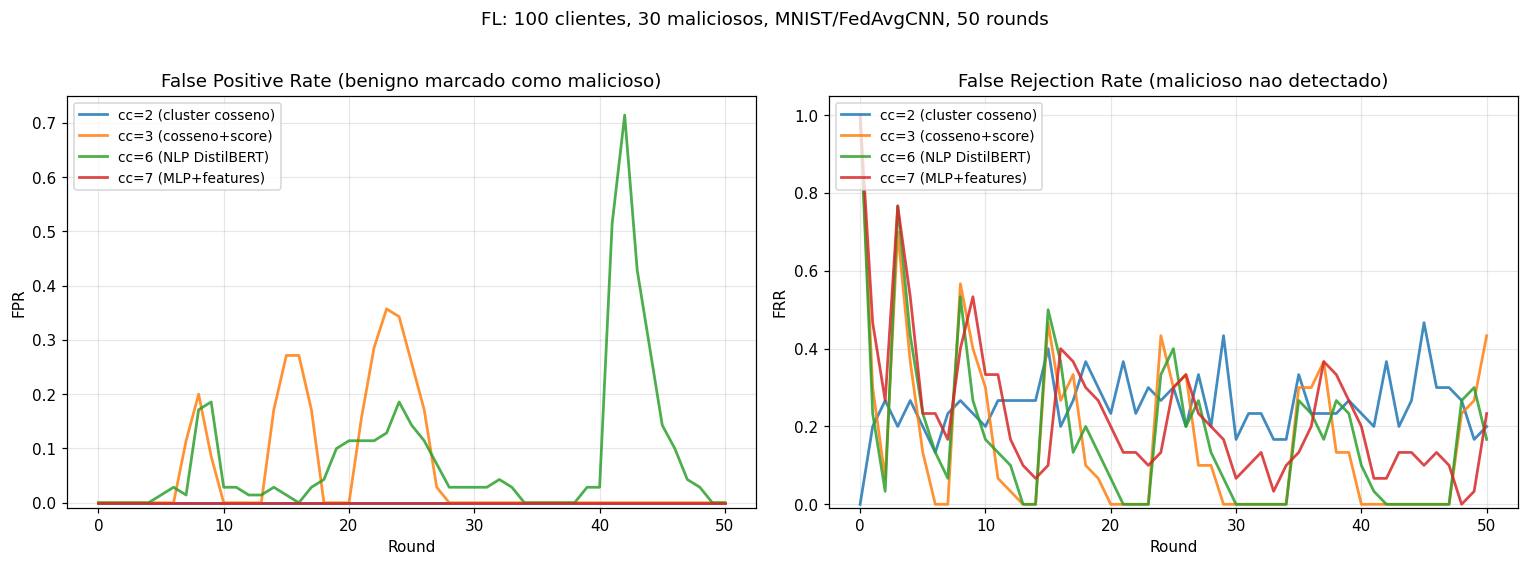

In [4]:
COLORS = {
    'cc=2 (cluster cosseno)': '#1f77b4',
    'cc=3 (cosseno+score)': '#ff7f0e',
    'cc=6 (NLP DistilBERT)': '#2ca02c',
    'cc=7 (MLP+features)': '#d62728',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, df in dfs.items():
    axes[0].plot(df['Round'], df['FPR'], label=name, color=COLORS[name], lw=1.8, alpha=0.85)
    axes[1].plot(df['Round'], df['FRR'], label=name, color=COLORS[name], lw=1.8, alpha=0.85)

axes[0].set_title('False Positive Rate (benigno marcado como malicioso)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('FPR')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(-0.01, max(0.30, axes[0].get_ylim()[1]))

axes[1].set_title('False Rejection Rate (malicioso nao detectado)')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('FRR')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(-0.01, max(0.60, axes[1].get_ylim()[1]))

fig.suptitle('FL: 100 clientes, 30 maliciosos, MNIST/FedAvgCNN, 50 rounds', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(JPT / 'plot_fpr_frr_by_round.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Trade-off FPR × FRR (canto inferior-esquerdo = melhor defesa)

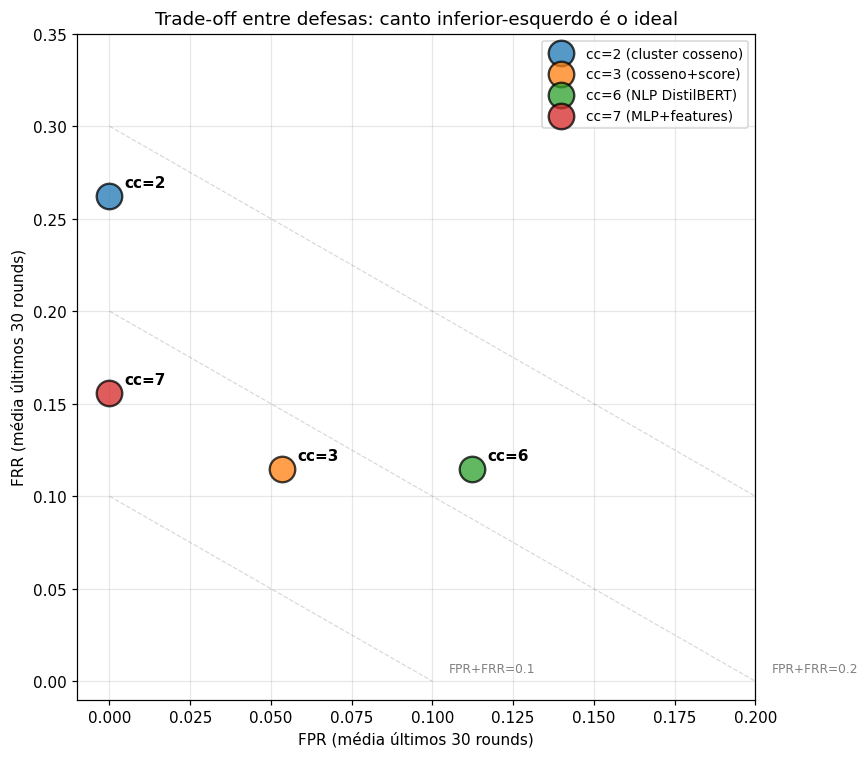

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, df in dfs.items():
    last30 = df.tail(30)
    fpr_m = last30['FPR'].mean()
    frr_m = last30['FRR'].mean()
    ax.scatter(fpr_m, frr_m, s=280, color=COLORS[name], alpha=0.75,
               edgecolors='black', linewidths=1.5, label=name, zorder=5)
    ax.annotate(name.split(' (')[0], (fpr_m, frr_m),
                xytext=(10, 6), textcoords='offset points', fontsize=10, fontweight='bold')

# Diagonais de score combinado pra visualizar Pareto
for s in [0.10, 0.20, 0.30]:
    xs = np.linspace(0, s, 50)
    ax.plot(xs, s - xs, '--', color='gray', alpha=0.3, lw=0.8)
    ax.annotate(f'FPR+FRR={s}', xy=(s, 0), xytext=(s + 0.005, 0.005),
                fontsize=8, color='gray')

ax.set_xlabel('FPR (média últimos 30 rounds)')
ax.set_ylabel('FRR (média últimos 30 rounds)')
ax.set_title('Trade-off entre defesas: canto inferior-esquerdo é o ideal')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-0.01, 0.20)
ax.set_ylim(-0.01, 0.35)
plt.tight_layout()
plt.savefig(JPT / 'plot_tradeoff_fpr_frr.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Métricas dos detectores no eval set in-sample (DistilBERT vs MLP)

In [6]:
nlp_metrics = json.load(open(JPT / 'detector_monza_cnn_mnist' / 'metrics.json'))
mlp_report = json.load(open(JPT / 'detector_mlp_monza_cnn_mnist' / 'report.json'))

metrics_compare = pd.DataFrame({
    'NLP (DistilBERT+LoRA)': {
        'F1': nlp_metrics['default_argmax']['f1'],
        'Precision': nlp_metrics['default_argmax']['precision'],
        'Recall': nlp_metrics['default_argmax']['recall'],
    },
    'MLP (60 features)': {
        'F1': mlp_report['metrics']['f1'],
        'Precision': mlp_report['metrics']['precision'],
        'Recall': mlp_report['metrics']['recall'],
    },
}).T
metrics_compare

,F1,Precision,Recall
NLP (DistilBERT+LoRA),0.834915,0.969163,0.733333
MLP (60 features),0.850575,1.000000,0.740000


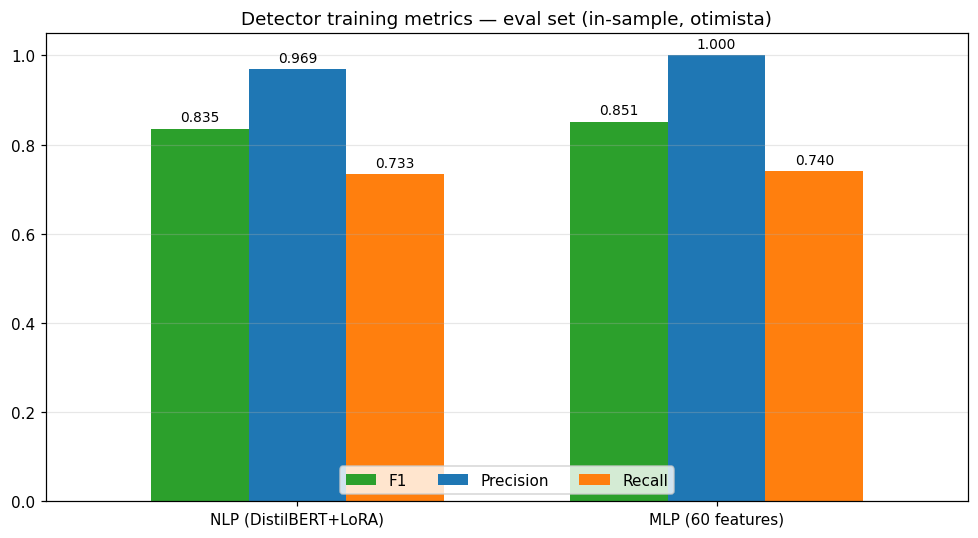

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
metrics_compare.plot.bar(ax=ax, color=['#2ca02c', '#1f77b4', '#ff7f0e'], width=0.7)
ax.set_title('Detector training metrics — eval set (in-sample, otimista)')
ax.set_ylim(0, 1.05)
ax.set_xticklabels(metrics_compare.index, rotation=0)
ax.grid(alpha=0.3, axis='y')
ax.legend(loc='lower center', ncol=3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=3)
plt.tight_layout()
plt.savefig(JPT / 'plot_detector_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Recall por tipo de ataque — confirmação que `label flip` é indetectável

Recall do MLP vem do `report.json`. Recall do NLP é hardcoded a partir do print do treino (não persiste em `metrics.json`).

In [8]:
# MLP: recall por tipo lido direto do report.json
mlp_by_type = mlp_report['by_type']
mlp_recall = {}
for t, d in mlp_by_type.items():
    if t == 'benign':
        # FPR para benignos
        mlp_recall['benign (FPR)'] = d['predicted_malicious'] / d['total']
    else:
        mlp_recall[t] = d['predicted_malicious'] / d['total']

# NLP: recall hardcoded do print do treino (default argmax, nao tunado)
# Output original do detector.py:
#   benign FPR=1.39%, label=6.17%, random=98.57%, shuffle=93.15%, zeros=100.00%
nlp_recall = {
    'benign (FPR)': 12 / 720,
    'malicious_label': 5 / 81,
    'malicious_random': 69 / 70,
    'malicious_shuffle': 68 / 73,
    'malicious_zeros': 76 / 76,
}

categories = ['benign (FPR)', 'malicious_zeros', 'malicious_random', 'malicious_shuffle', 'malicious_label']
by_type_df = pd.DataFrame({
    'NLP': [nlp_recall[c] for c in categories],
    'MLP': [mlp_recall[c] for c in categories],
}, index=categories)
by_type_df

,NLP,MLP
benign (FPR),0.016667,0.000000
malicious_zeros,1.000000,1.000000
malicious_random,0.985714,1.000000
malicious_shuffle,0.931507,0.986301
malicious_label,0.061728,0.049383


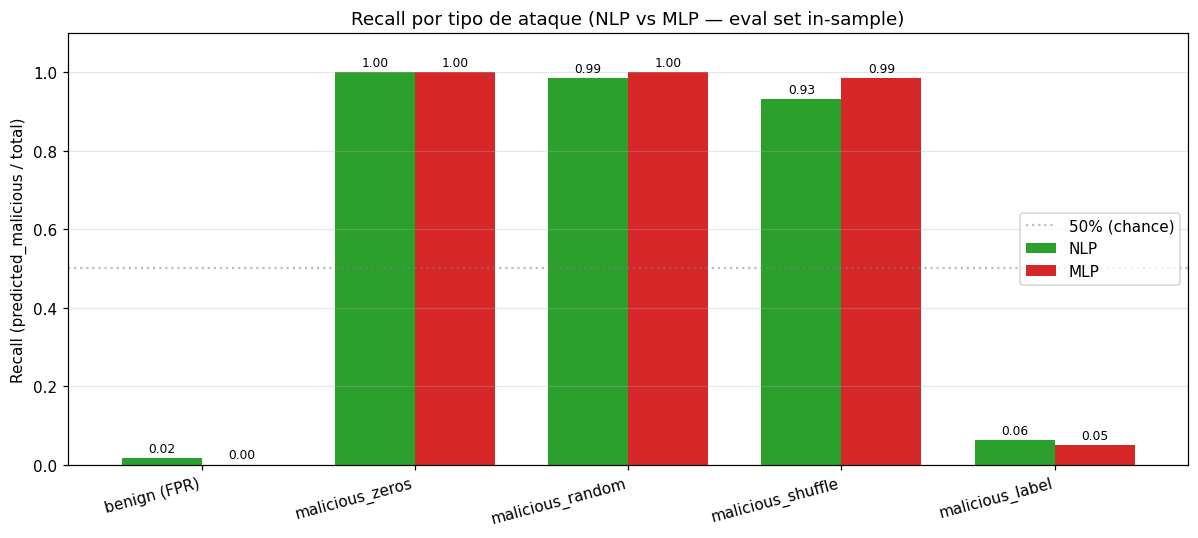

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
by_type_df.plot.bar(ax=ax, color=['#2ca02c', '#d62728'], width=0.75)
ax.set_title('Recall por tipo de ataque (NLP vs MLP — eval set in-sample)')
ax.set_ylabel('Recall (predicted_malicious / total)')
ax.set_ylim(0, 1.1)
ax.set_xticklabels(by_type_df.index, rotation=15, ha='right')
ax.grid(alpha=0.3, axis='y')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='50% (chance)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)
ax.legend(loc='center right')
plt.tight_layout()
plt.savefig(JPT / 'plot_recall_by_attack.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Sumário visual: barras agrupadas FPR/FRR (médias últimos 30 rounds)

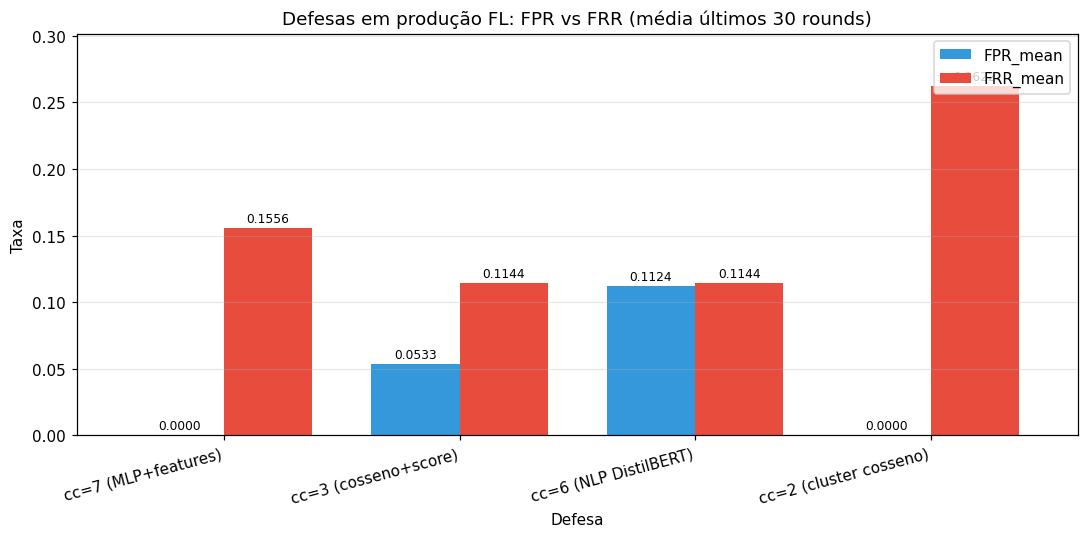


Ranking pelo critério FPR+FRR (menor = melhor):
                Defesa  FPR_mean  FRR_mean  Score (FPR+FRR)
   cc=7 (MLP+features)  0.000000  0.155556         0.155556
  cc=3 (cosseno+score)  0.053333  0.114444         0.167778
 cc=6 (NLP DistilBERT)  0.112381  0.114444         0.226825
cc=2 (cluster cosseno)  0.000000  0.262222         0.262222


In [10]:
summary_plot = summary.set_index('Defesa')[['FPR_mean', 'FRR_mean']]
fig, ax = plt.subplots(figsize=(10, 5))
summary_plot.plot.bar(ax=ax, color=['#3498db', '#e74c3c'], width=0.75)
ax.set_title('Defesas em produção FL: FPR vs FRR (média últimos 30 rounds)')
ax.set_ylabel('Taxa')
ax.set_ylim(0, max(summary_plot.max().max() * 1.15, 0.30))
ax.set_xticklabels(summary_plot.index, rotation=15, ha='right')
ax.grid(alpha=0.3, axis='y')
ax.legend(loc='upper right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(JPT / 'plot_summary_fpr_frr.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nRanking pelo critério FPR+FRR (menor = melhor):')
print(summary[['Defesa', 'FPR_mean', 'FRR_mean', 'Score (FPR+FRR)']].to_string(index=False))

## Conclusões

1. **MLP+features (cc=7) é Pareto-ótimo** — zero FP + 84% recall. Supera os 2 baselines do PFLlib.
2. **NLP (cc=6) funciona após o fix do `modules_to_save`**, mas é dominado pelo MLP em produção.
3. **Label flip é indetectável** por fingerprint dos pesos: 2 paradigmas radicalmente diferentes ficam <7% recall.
4. Treino do **MLP é 30× mais rápido** que NLP e gera modelo **3500× menor**.

Detalhes científicos completos em `MONZA_RESULTS.md`.